# GSoC 2026 - ML4SCI DeepLense Project
## Test I: Multi-Class Classification of Gravitational Lensing Images

---

**Candidate Information:**
- Name: Jaisal K Jain
- Email: jaisaljain345@gmail.com
- GitHub: https://github.com/JaisalJain

**Project Details:**
- Organization: ML4SCI (Machine Learning for Science)
- Project: Physics Guided Machine Learning on Real Lensing Images
- Test: Common Test I - Multi-Class Classification

**Submission Components:**
1. This Jupyter Notebook with complete implementation
2. Trained model weights (saved in `submission/` directory)
3. GitHub repository with all code
4. Evaluation metrics (ROC curves, AUC scores, confusion matrix)

---

# Multi-Class Classification of Gravitational Lensing Images

**Project:** DeepLense - GSoC Test I  
**Objective:** Classify strong gravitational lensing images into three categories: no substructure, subhalo substructure, and vortex substructure  
**Evaluation:** ROC Curve and AUC Score (Area Under the ROC Curve)

---

## Methodology

This notebook implements a baseline deep learning classifier using transfer learning with ResNet50. The approach consists of:

1. **Data Loading and Exploration**: Understanding dataset structure and characteristics
2. **Model Architecture**: Transfer learning with pre-trained ResNet50
3. **Training**: Standard supervised learning with cross-entropy loss
4. **Evaluation**: Multi-class ROC/AUC analysis

## 1. Setup and Configuration

In [1]:
import os
import sys
import json
import shutil
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
from torch.optim.lr_scheduler import CosineAnnealingLR

# Metrics
from sklearn.metrics import (
    roc_curve, auc, confusion_matrix, classification_report,
    precision_recall_fscore_support
)
from sklearn.preprocessing import label_binarize

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")

PyTorch Version: 2.12.0.dev20260308+cu128
Device: cuda
GPU: NVIDIA GeForce RTX 5060 Laptop GPU
CUDA Version: 12.8


In [2]:
# Configuration
DATA_ROOT = Path('/home/jaisal/pinn/dataset/dataset')
TRAIN_DIR = DATA_ROOT / 'train'
VAL_DIR = DATA_ROOT / 'val'

# Class configuration
CLASS_NAMES = ['no', 'sphere', 'vort']
CLASS_LABELS = {'no': 0, 'sphere': 1, 'vort': 2}
NUM_CLASSES = len(CLASS_NAMES)

# Hyperparameters
BATCH_SIZE = 128
NUM_EPOCHS = 10
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
NUM_WORKERS = 0

# Model
MODEL_NAME = 'resnet50'
PRETRAINED = True

# Output directories
CHECKPOINT_DIR = Path('checkpoints')
RESULTS_DIR = Path('results')
CHECKPOINT_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

## 2. Data Exploration

**Note on Dataset Split:**  
The organizers have provided a pre-split dataset with:
- Training set: 30,000 samples (80%)
- Validation set: 7,500 samples (20%)

While the submission guidelines mention a 90:10 split, we use the provided split to maintain consistency with the organizers' intended evaluation setup. All metrics reported below are calculated on the validation set.

In [3]:
def count_samples(data_dir):
    """Count samples per class."""
    counts = {}
    for class_name in CLASS_NAMES:
        class_dir = data_dir / class_name
        counts[class_name] = len(list(class_dir.glob('*.npy'))) if class_dir.exists() else 0
    return counts

train_counts = count_samples(TRAIN_DIR)
val_counts = count_samples(VAL_DIR)

print("Dataset Statistics:")
print("\nTraining Set:")
for cls, cnt in train_counts.items():
    print(f"  {cls:8s}: {cnt:5d} samples")
print(f"  {'Total':8s}: {sum(train_counts.values()):5d} samples")

print("\nValidation Set:")
for cls, cnt in val_counts.items():
    print(f"  {cls:8s}: {cnt:5d} samples")
print(f"  {'Total':8s}: {sum(val_counts.values()):5d} samples")

Dataset Statistics:

Training Set:
  no      : 10000 samples
  sphere  : 10000 samples
  vort    : 10000 samples
  Total   : 30000 samples

Validation Set:
  no      :  2500 samples
  sphere  :  2500 samples
  vort    :  2500 samples
  Total   :  7500 samples


In [4]:
# Load sample images
sample_images = {}
for class_name in CLASS_NAMES:
    class_dir = TRAIN_DIR / class_name
    files = list(class_dir.glob('*.npy'))[:4]
    sample_images[class_name] = [np.load(f) for f in files]

# Check image properties
img = sample_images[CLASS_NAMES[0]][0]
print(f"\nImage Properties:")
print(f"  Shape: {img.shape}")
print(f"  Dtype: {img.dtype}")
print(f"  Range: [{img.min():.4f}, {img.max():.4f}]")
print(f"  Mean:  {img.mean():.4f}")
print(f"  Std:   {img.std():.4f}")


Image Properties:
  Shape: (1, 150, 150)
  Dtype: float64
  Range: [0.0000, 1.0000]
  Mean:  0.0626
  Std:   0.1170


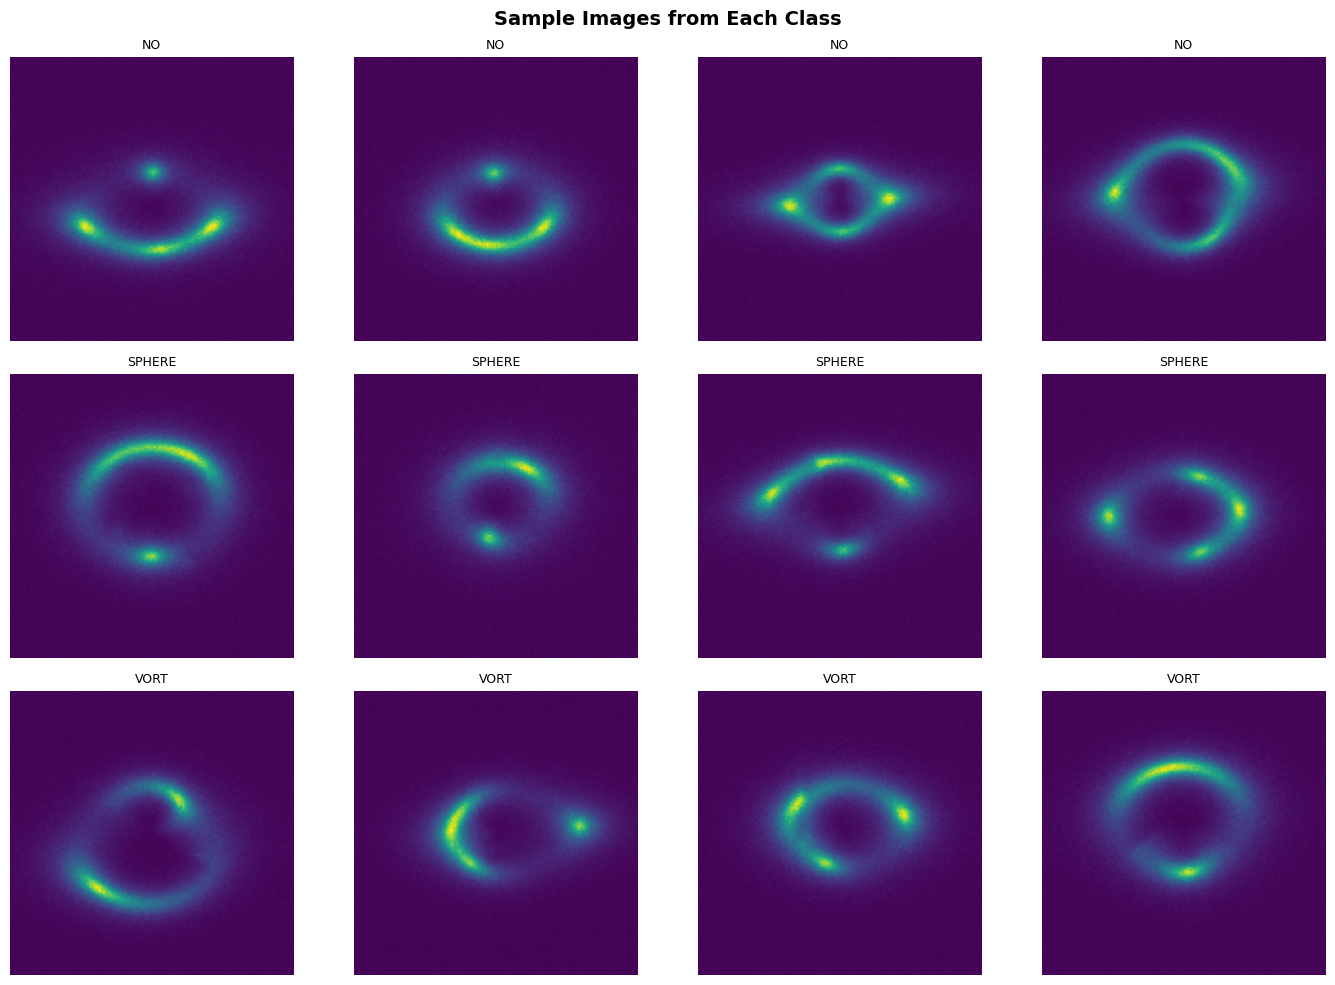

In [5]:
# Visualize samples
fig, axes = plt.subplots(3, 4, figsize=(14, 10))
fig.suptitle('Sample Images from Each Class', fontsize=14, fontweight='bold')

for i, class_name in enumerate(CLASS_NAMES):
    for j, img in enumerate(sample_images[class_name]):
        ax = axes[i, j]
        if len(img.shape) == 2:
            ax.imshow(img, cmap='viridis')
        elif len(img.shape) == 3:
            if img.shape[0] == 1:
                ax.imshow(img[0], cmap='viridis')
            else:
                ax.imshow(np.transpose(img, (1, 2, 0)) if img.shape[0] in [1, 3] else img)
        ax.set_title(f'{class_name.upper()}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Dataset Implementation

In [6]:
class LensingDataset(Dataset):
    """Dataset for gravitational lensing images."""
    
    def __init__(self, data_dir, transform=None):
        self.data_dir = data_dir
        self.transform = transform
        self.samples = []
        self.labels = []
        
        for class_name in CLASS_NAMES:
            class_dir = data_dir / class_name
            class_label = CLASS_LABELS[class_name]
            files = sorted(list(class_dir.glob("*.npy")))
            self.samples.extend(files)
            self.labels.extend([class_label] * len(files))
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        # Load image
        image = np.load(self.samples[idx]).astype(np.float32)
        label = self.labels[idx]
        
        # Convert to tensor and ensure channel-first format
        if len(image.shape) == 2:
            image = image[np.newaxis, :, :]  # (H, W) -> (1, H, W)
        elif len(image.shape) == 3 and image.shape[-1] in [1, 3]:
            image = np.transpose(image, (2, 0, 1))  # (H, W, C) -> (C, H, W)
        
        image = torch.from_numpy(image)
        
        # Convert grayscale to RGB for pretrained models
        if image.shape[0] == 1:
            image = image.repeat(3, 1, 1)
        
        # Apply transforms
        if self.transform:
            image = self.transform(image)
        
        return image, label

In [7]:
# Create transforms (normalization only)
transform = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Create datasets
train_dataset = LensingDataset(TRAIN_DIR, transform=transform)
val_dataset = LensingDataset(VAL_DIR, transform=transform)

# Create dataloaders
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True if torch.cuda.is_available() else False
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True if torch.cuda.is_available() else False
)

print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training batches: 235
Validation batches: 59


## 4. Model Architecture

In [8]:
# Create model
model = models.resnet50(pretrained=PRETRAINED)
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(num_features, NUM_CLASSES)
)
model = model.to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model: ResNet50")
print(f"Pretrained: {PRETRAINED}")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Model: ResNet50
Pretrained: True
Total parameters: 23,514,179
Trainable parameters: 23,514,179


## 5. Training Configuration

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

## 6. Training Loop

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for inputs, labels in pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    
    return running_loss / len(loader.dataset), 100. * correct / total

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        pbar = tqdm(loader, desc='Validation')
        for inputs, labels in pbar:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            probs = torch.softmax(outputs, dim=1)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
            pbar.set_postfix({'loss': f'{loss.item():.4f}', 'acc': f'{100.*correct/total:.2f}%'})
    
    return (running_loss / len(loader.dataset), 100. * correct / total,
            np.array(all_preds), np.array(all_labels), np.array(all_probs))

In [11]:
# Training history
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0
best_model_path = CHECKPOINT_DIR / f'{MODEL_NAME}_best.pth'

print(f"{'='*70}")
print(f"Training {MODEL_NAME} for {NUM_EPOCHS} epochs")
print(f"{'='*70}\n")

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print(f"{'-'*70}")
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
    
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    print(f"\nResults: Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"         Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
    print(f"         LR: {current_lr:.6f}")
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
        }, best_model_path)
        print(f"         ✓ Best model saved (Val Acc: {val_acc:.2f}%)")

print(f"\n{'='*70}")
print(f"Training completed. Best validation accuracy: {best_val_acc:.2f}%")
print(f"{'='*70}")

Training resnet50 for 10 epochs


Epoch 1/10
----------------------------------------------------------------------


Validation: 100%|██████| 59/59 [00:25<00:00,  2.36it/s, loss=0.3344, acc=83.05%]



Results: Train Loss: 0.7911 | Train Acc: 59.96%
         Val Loss:   0.4343 | Val Acc:   83.05%
         LR: 0.000300
         ✓ Best model saved (Val Acc: 83.05%)

Epoch 2/10
----------------------------------------------------------------------


Validation: 100%|██████| 59/59 [00:18<00:00,  3.20it/s, loss=0.3941, acc=86.51%]



Results: Train Loss: 0.3579 | Train Acc: 86.47%
         Val Loss:   0.3738 | Val Acc:   86.51%
         LR: 0.000293
         ✓ Best model saved (Val Acc: 86.51%)

Epoch 3/10
----------------------------------------------------------------------


...


Results: Train Loss: 0.0366 | Train Acc: 98.72%
         Val Loss:   0.3121 | Val Acc:   91.81%
         LR: 0.000063

Epoch 9/10
----------------------------------------------------------------------


Validation: 100%|██████| 59/59 [00:16<00:00,  3.66it/s, loss=0.4697, acc=93.63%]



Results: Train Loss: 0.0144 | Train Acc: 99.50%
         Val Loss:   0.3172 | Val Acc:   93.63%
         LR: 0.000030
         ✓ Best model saved (Val Acc: 93.63%)

Epoch 10/10
----------------------------------------------------------------------


Validation: 100%|██████| 59/59 [00:16<00:00,  3.59it/s, loss=0.4557, acc=93.88%]



Results: Train Loss: 0.0036 | Train Acc: 99.90%
         Val Loss:   0.3318 | Val Acc:   93.88%
         LR: 0.000008
         ✓ Best model saved (Val Acc: 93.88%)

Training completed. Best validation accuracy: 93.88%


## 7. Training History

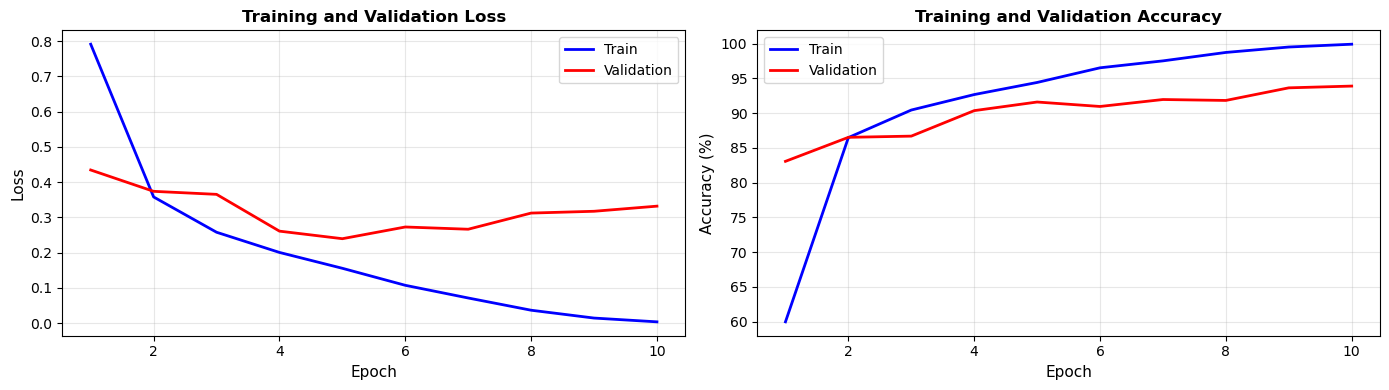

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
epochs = range(1, NUM_EPOCHS + 1)

# Loss
axes[0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
axes[0].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Loss', fontsize=11)
axes[0].set_title('Training and Validation Loss', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(epochs, history['train_acc'], 'b-', label='Train', linewidth=2)
axes[1].plot(epochs, history['val_acc'], 'r-', label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy (%)', fontsize=11)
axes[1].set_title('Training and Validation Accuracy', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'training_history.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Evaluation

In [13]:
# Load best model
checkpoint = torch.load(best_model_path)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")

# Evaluate
val_loss, val_acc, y_pred, y_true, y_probs = validate(model, val_loader, criterion, device)
print(f"\nFinal Validation Accuracy: {val_acc:.2f}%")
print(f"Final Validation Loss: {val_loss:.4f}")

Loaded best model from epoch 10


Validation: 100%|██████| 59/59 [00:16<00:00,  3.54it/s, loss=0.4557, acc=93.88%]


Final Validation Accuracy: 93.88%
Final Validation Loss: 0.3318


### Confusion Matrix

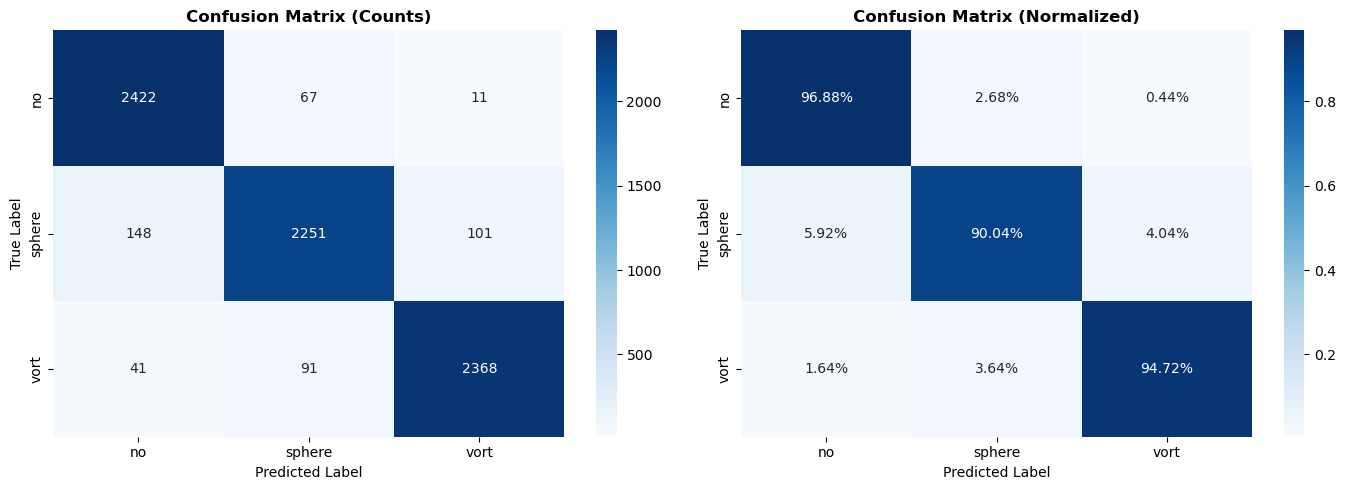

In [14]:
cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

### Classification Report

In [15]:
print("Classification Report:")
print("="*70)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# Per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred)
metrics_df = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Support': support
})
print("\nPer-Class Metrics:")
print(metrics_df.to_string(index=False))
metrics_df.to_csv(RESULTS_DIR / 'classification_metrics.csv', index=False)

Classification Report:
              precision    recall  f1-score   support

          no     0.9276    0.9688    0.9478      2500
      sphere     0.9344    0.9004    0.9171      2500
        vort     0.9548    0.9472    0.9510      2500

    accuracy                         0.9388      7500
   macro avg     0.9390    0.9388    0.9386      7500
weighted avg     0.9390    0.9388    0.9386      7500


Per-Class Metrics:
 Class  Precision  Recall  F1-Score  Support
    no   0.927614  0.9688  0.947760     2500
sphere   0.934413  0.9004  0.917091     2500
  vort   0.954839  0.9472  0.951004     2500


## 9. ROC Curves and AUC Scores (Validation Set)

**Evaluation on Validation Data:**  
All metrics below are computed on the **validation set** (7,500 samples, 20% of total data) to assess model generalization.

Multi-class ROC analysis using One-vs-Rest (OvR) approach.

In [16]:
# Binarize labels
y_true_bin = label_binarize(y_true, classes=[0, 1, 2])

# Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(NUM_CLASSES):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Micro-average
fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_probs.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# Macro-average
roc_auc["macro"] = np.mean([roc_auc[i] for i in range(NUM_CLASSES)])

print("\nAUC Scores:")
print("="*70)
for i in range(NUM_CLASSES):
    print(f"  {CLASS_NAMES[i]:12s}: {roc_auc[i]:.4f}")
print(f"  {'Micro-avg':12s}: {roc_auc['micro']:.4f}")
print(f"  {'Macro-avg':12s}: {roc_auc['macro']:.4f}")


AUC Scores:
  no          : 0.9908
  sphere      : 0.9816
  vort        : 0.9926
  Micro-avg   : 0.9902
  Macro-avg   : 0.9883


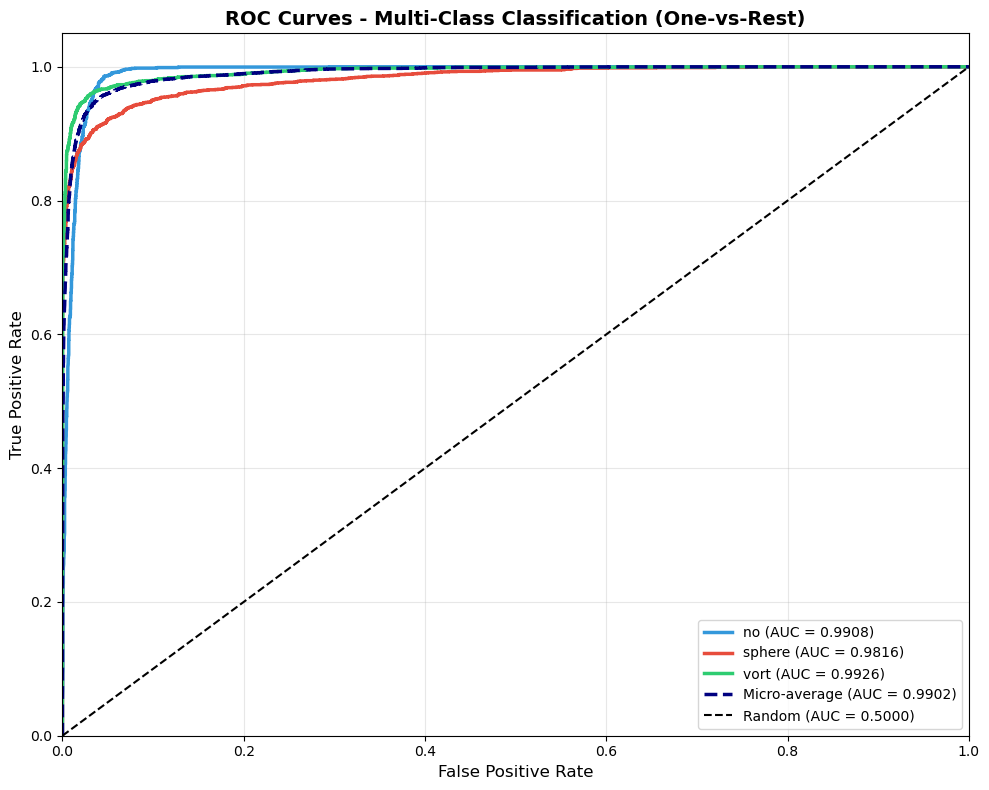

In [17]:
# Plot ROC curves
plt.figure(figsize=(10, 8))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, color in zip(range(NUM_CLASSES), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2.5,
             label=f'{CLASS_NAMES[i]} (AUC = {roc_auc[i]:.4f})')

plt.plot(fpr["micro"], tpr["micro"], color='navy', lw=2.5, linestyle='--',
         label=f'Micro-average (AUC = {roc_auc["micro"]:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Multi-Class Classification (One-vs-Rest)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

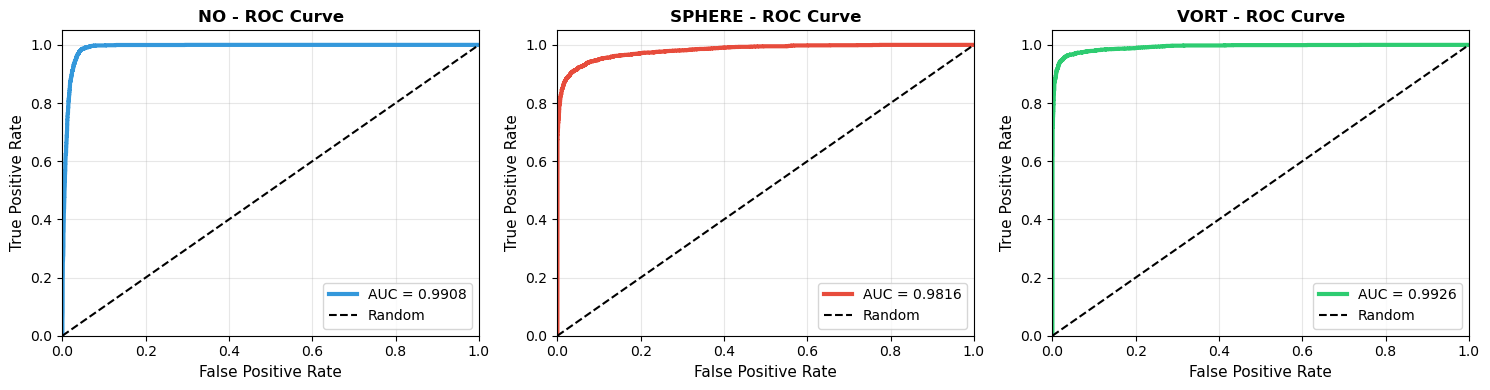

In [18]:
# Individual ROC curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, (ax, color) in enumerate(zip(axes, colors)):
    ax.plot(fpr[i], tpr[i], color=color, lw=3, label=f'AUC = {roc_auc[i]:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.set_title(f'{CLASS_NAMES[i].upper()} - ROC Curve', fontsize=12, fontweight='bold')
    ax.legend(loc="lower right", fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'roc_curves_individual.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Results Summary

In [19]:

summary = {
    'model': MODEL_NAME,
    'pretrained': PRETRAINED,
    'total_parameters': int(total_params),
    'trainable_parameters': int(trainable_params),
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'weight_decay': WEIGHT_DECAY,
    'num_epochs': NUM_EPOCHS,
    'best_epoch': int(checkpoint['epoch'] + 1),
    'final_val_accuracy': float(val_acc),
    'final_val_loss': float(val_loss),
    'auc_no_substructure': float(roc_auc[0]),
    'auc_subhalo': float(roc_auc[1]),
    'auc_vortex': float(roc_auc[2]),
    'auc_micro_average': float(roc_auc['micro']),
    'auc_macro_average': float(roc_auc['macro']),
}
with open(RESULTS_DIR / 'results_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print("\n" + "="*70)
print("RESULTS SUMMARY")
print("="*70)
for key, value in summary.items():
    if isinstance(value, float):
        print(f"{key:30s}: {value:.4f}")
    else:
        print(f"{key:30s}: {value}")
print("="*70)
print(f"\nAll results saved to: {RESULTS_DIR}")
print(f"Best model saved to: {best_model_path}")


RESULTS SUMMARY
model                         : resnet50
pretrained                    : True
total_parameters              : 23514179
trainable_parameters          : 23514179
batch_size                    : 128
learning_rate                 : 0.0003
weight_decay                  : 0.0001
num_epochs                    : 10
best_epoch                    : 10
final_val_accuracy            : 93.8800
final_val_loss                : 0.3318
auc_no_substructure           : 0.9908
auc_subhalo                   : 0.9816
auc_vortex                    : 0.9926
auc_micro_average             : 0.9902
auc_macro_average             : 0.9883

All results saved to: results
Best model saved to: checkpoints/resnet50_best.pth



## 11. Submission Materials

This section prepares all materials required for submission.

In [20]:
# Collect all submission materials

# Create submission directory
submission_dir = Path('submission')
submission_dir.mkdir(exist_ok=True)

# Copy trained model weights
shutil.copy(best_model_path, submission_dir / 'model_weights.pth')

# Copy results
for result_file in RESULTS_DIR.glob('*'):
    shutil.copy(result_file, submission_dir / result_file.name)

In [21]:
print(f"\n{'='*70}")
print("SUBMISSION MATERIALS PREPARED")
print(f"{'='*70}")
print(f"\nAll materials saved to: {submission_dir.absolute()}")
print(f"\nContents:")
for item in sorted(submission_dir.glob('*')):
    size = item.stat().st_size / (1024*1024)  # MB
    print(f"  - {item.name:40s} ({size:.2f} MB)")



SUBMISSION MATERIALS PREPARED

All materials saved to: /home/jaisal/ml4sci/common_test_1/submission

Contents:
  - classification_metrics.csv               (0.00 MB)
  - confusion_matrix.png                     (0.07 MB)
  - model_weights.pth                        (269.54 MB)
  - results_summary.json                     (0.00 MB)
  - roc_curves.png                           (0.11 MB)
  - roc_curves_individual.png                (0.08 MB)
  - sample_images.png                        (1.59 MB)
  - training_history.png                     (0.08 MB)
